In [1]:
import scipy.io
import io
 
from data_loader import DataLoader

import numpy as np
from utils import *
from matplotlib import pyplot as plt
import numpy.random as rng
import pandas as pd
from scipy.stats import mannwhitneyu

import os

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
%run functions_to_use.ipynb
%run results_plots.ipynb

In [3]:
def flatten(xss):
    return [x for xs in xss for x in xs]

In [4]:
import pickle

with open("results_rat_11_puff_cos_70-30_56101213.pkl", "rb") as pkl_file:
    rat11_puff = pickle.load(pkl_file)

with open("results_rat_10_puff_70-30.pkl", "rb") as pkl_file:
    rat10_puff = pickle.load(pkl_file)

with open("results_rat_8_puff_70-30.pkl" , "rb") as pkl_file:
    rat8_puff = pickle.load(pkl_file)

In [5]:
rat11_puff[5]

{'session': 12,
 'sequence': {'neurons': array([38]), 'order': array([nan])},
 'puff_results': {'time_points': [11653451,
   11653471,
   11653491,
   11676476,
   11676496,
   11676516,
   11700680,
   11700700,
   11700720,
   11795245,
   11795265,
   11795285,
   11849315,
   11849335,
   11849355,
   11930048,
   11930068,
   11930088,
   12008720,
   12008740,
   12008760,
   12029758,
   12029778,
   12029798,
   12184213,
   12184233,
   12184253,
   12344883,
   12344903,
   12344923,
   12400735,
   12400755,
   12400775,
   12511461,
   12511481,
   12511501],
  'values': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0]},
 'safe_results': {'time_points': [11526553,
   11526573,
   11526593,
   11554073,
   11554093,
   11554113,
   11611648,


# Normal method

In [6]:
# GET PUFF VARIABLES
# RAT 11

puff_0_puff_values = np.nan_to_num(rat11_puff[0]['puff_results']['values'])
puff_0_puff_time = rat11_puff[0]['puff_results']['time_points']

puff_0_safe_values = np.nan_to_num(rat11_puff[0]['safe_results']['values'])
puff_0_safe_time = rat11_puff[0]['safe_results']['time_points']

puff_0_pre_values = np.nan_to_num(rat11_puff[0]['pre_results']['values'])
puff_0_pre_time = rat11_puff[0]['pre_results']['time_points']

puff_0_post_values = np.nan_to_num(rat11_puff[0]['post_results']['values'])
puff_0_post_time = rat11_puff[0]['post_results']['time_points']

puff_1_puff_values = np.nan_to_num(rat11_puff[1]['puff_results']['values'])
puff_1_puff_time = rat11_puff[1]['puff_results']['time_points']

puff_1_safe_values = np.nan_to_num(rat11_puff[1]['safe_results']['values'])
puff_1_safe_time = np.nan_to_num(rat11_puff[1]['safe_results']['time_points'])

puff_1_pre_values = np.nan_to_num(rat11_puff[1]['pre_results']['values'])
puff_1_pre_time = np.nan_to_num(rat11_puff[1]['pre_results']['time_points'])

puff_1_post_values = np.nan_to_num(rat11_puff[1]['post_results']['values'])
puff_1_post_time = rat11_puff[1]['post_results']['time_points']

puff_2_puff_values = np.nan_to_num(rat11_puff[4]['puff_results']['values'])
puff_2_puff_time = rat11_puff[4]['puff_results']['time_points']

puff_2_safe_values = np.nan_to_num(rat11_puff[4]['safe_results']['values'])
puff_2_safe_time = rat11_puff[4]['safe_results']['time_points']

puff_2_pre_values = np.nan_to_num(rat11_puff[4]['pre_results']['values'])
puff_2_pre_time = rat11_puff[4]['pre_results']['time_points']

puff_2_post_values = np.nan_to_num(rat11_puff[4]['post_results']['values'])
puff_2_post_time = rat11_puff[4]['post_results']['time_points']

puff_3_puff_values = np.nan_to_num(rat11_puff[5]['puff_results']['values'])
puff_3_puff_time = rat11_puff[5]['puff_results']['time_points']

puff_3_safe_values = np.nan_to_num(rat11_puff[5]['safe_results']['values'])
puff_3_safe_time = np.nan_to_num(rat11_puff[5]['safe_results']['time_points'])

puff_3_pre_values = np.nan_to_num(rat11_puff[5]['pre_results']['values'])
puff_3_pre_time = np.nan_to_num(rat11_puff[5]['pre_results']['time_points'])

puff_3_post_values = np.nan_to_num(rat11_puff[5]['post_results']['values'])
puff_3_post_time = rat11_puff[5]['post_results']['time_points']

puff_4_puff_values = np.nan_to_num(rat11_puff[6]['puff_results']['values'])
puff_4_puff_time = rat11_puff[6]['puff_results']['time_points']

puff_4_safe_values = np.nan_to_num(rat11_puff[6]['safe_results']['values'])
puff_4_safe_time = rat11_puff[6]['safe_results']['time_points']

puff_4_pre_values = np.nan_to_num(rat11_puff[6]['pre_results']['values'])
puff_4_pre_time = rat11_puff[6]['pre_results']['time_points']

puff_4_post_values = np.nan_to_num(rat11_puff[6]['post_results']['values'])
puff_4_post_time = rat11_puff[6]['post_results']['time_points']

# RAT 10

puff_5_puff_values = np.nan_to_num(rat10_puff[5]['puff_results']['values'])
puff_5_puff_time = rat10_puff[5]['puff_results']['time_points']

puff_5_safe_values = np.nan_to_num(rat10_puff[5]['safe_results']['values'])
puff_5_safe_time = rat10_puff[5]['safe_results']['time_points']

puff_5_pre_values = np.nan_to_num(rat10_puff[5]['pre_results']['values'])
puff_5_pre_time = rat10_puff[5]['pre_results']['time_points']

puff_5_post_values = np.nan_to_num(rat10_puff[5]['post_results']['values'])
puff_5_post_time = rat10_puff[5]['post_results']['time_points']

# RAT 08

puff_6_puff_values = np.nan_to_num(rat8_puff[0]['puff_results']['values'])
puff_6_puff_time = rat8_puff[0]['puff_results']['time_points']

puff_6_safe_values = np.nan_to_num(rat8_puff[0]['safe_results']['values'])
puff_6_safe_time = rat8_puff[0]['safe_results']['time_points']

puff_6_pre_values = np.nan_to_num(rat8_puff[0]['pre_results']['values'])
puff_6_pre_time = rat8_puff[0]['pre_results']['time_points']

puff_6_post_values = np.nan_to_num(rat8_puff[0]['post_results']['values'])
puff_6_post_time = rat8_puff[0]['post_results']['time_points']



In [7]:
data_puff = [
    [puff_0_safe_values, puff_0_puff_values], 
    [puff_0_pre_values, puff_0_post_values], 
    [puff_1_safe_values, puff_1_puff_values],
    [puff_1_pre_values, puff_1_post_values],
    [puff_2_safe_values, puff_2_puff_values], 
    [puff_2_pre_values, puff_2_post_values], 
    [puff_3_safe_values, puff_3_puff_values],
    [puff_3_pre_values, puff_3_post_values],
    [puff_4_safe_values, puff_4_puff_values], 
    [puff_4_pre_values, puff_4_post_values], 
    [puff_5_safe_values, puff_5_puff_values], 
    [puff_5_pre_values, puff_5_post_values],
    [puff_6_safe_values, puff_6_puff_values], 
    [puff_6_pre_values, puff_6_post_values]]

data_puff_results = [
    [puff_0_safe_values, puff_0_puff_values], 
    [puff_0_pre_values, puff_0_post_values], 
    [puff_4_safe_values, puff_4_puff_values], 
    [puff_4_pre_values, puff_4_post_values],
    [puff_5_safe_values, puff_5_puff_values], 
    [puff_5_pre_values, puff_5_post_values]]

sample_0 = rng.choice(puff_0_safe_values, len(puff_0_puff_values), replace=False)
sample_4 = rng.choice(puff_4_safe_values, len(puff_4_puff_values), replace=False)
sample_5 = rng.choice(puff_5_safe_values, len(puff_5_puff_values), replace=False)

sample_0_p = rng.choice(puff_0_pre_values, len(puff_0_post_values), replace=False)
sample_4_p = rng.choice(puff_4_post_values, len(puff_4_pre_values), replace=False)
sample_5_p = rng.choice(puff_5_post_values, len(puff_5_pre_values), replace=False)

data_puff_sample = [
    [sample_0, puff_0_puff_values], 
    [sample_0_p, puff_0_post_values], 
    [sample_4, puff_4_puff_values], 
    [puff_4_pre_values, sample_4_p],
    [sample_5, puff_5_puff_values], 
    [puff_5_pre_values, sample_5_p]]

len(puff_0_puff_values)

# significance test
for i, (val_1, val_2) in enumerate(data_puff_sample):
    stat, p_value = mannwhitneyu(val_1, val_2, alternative='two-sided')
    if(i % 2 == 0):
        print(f"Mann Whitney U between Puff/Safe is: {stat}, with P-value: {p_value}")
    else:
        print(f"Mann Whitney U between Pre/Post is: {stat}, with P-value: {p_value}, \n")

Mann Whitney U between Puff/Safe is: 1038.0, with P-value: 0.11096721027545976
Mann Whitney U between Pre/Post is: 1515703.0, with P-value: 1.1223905230213785e-10, 

Mann Whitney U between Puff/Safe is: 132.5, with P-value: 0.01020479020727737
Mann Whitney U between Pre/Post is: 7836566.5, with P-value: 5.798107729169666e-05, 

Mann Whitney U between Puff/Safe is: 60.0, with P-value: 0.16582395411666384
Mann Whitney U between Pre/Post is: 3905851.0, with P-value: 0.002746088934536418, 



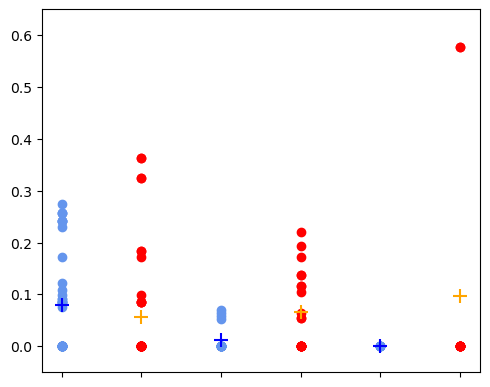

In [8]:
x_positions = [0, 1, 2, 3, 4, 5]
plt.figure(figsize=(5,4))
values_1, values_2 = sample_0, puff_0_puff_values
for i in range(len(values_1)):
    plt.scatter(x_positions[0], values_1[i], color='cornflowerblue', label='Safe' if i == 0 else "")
    plt.scatter(x_positions[1], values_2[i], color='red', label='Puff' if i == 0 else "")
plt.scatter(x_positions[0], np.mean(values_1), marker='+', s=100, color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[1], np.mean(values_2), marker='+', s=100, color='orange', label='Safe' if i == 0 else "")

values_1, values_2 = sample_4, puff_4_puff_values
for i in range(len(values_1)):
    plt.scatter(x_positions[2], values_1[i], color='cornflowerblue', label='Safe' if i == 0 else "")
    plt.scatter(x_positions[3], values_2[i], color='red', label='Puff' if i == 0 else "")
plt.scatter(x_positions[2], np.mean(values_1), marker='+', s=100, color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[3], np.mean(values_2), marker='+', s=100, color='orange', label='Safe' if i == 0 else "")

values_1, values_2 = sample_5, puff_5_puff_values
for i in range(len(values_1)):
    plt.scatter(x_positions[4], values_1[i], color='cornflowerblue', label='Safe' if i == 0 else "")
    plt.scatter(x_positions[5], values_2[i], color='red', label='Puff' if i == 0 else "")
plt.scatter(x_positions[4], np.mean(values_1), marker='+', s=100, color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[5], np.mean(values_2), marker='+', s=100, color='orange', label='Safe' if i == 0 else "")

plt.xticks(x_positions, [])
# plt.yticks([])# Set the x-tick labels to 'First Half' and 'Second Half'
# plt.ylabel('Projection value')
# plt.title('Projection values for Safe and Puff runs')
# plt.legend()
# plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.ylim(-0.05, 0.65)
plt.savefig('diff_puff_safe.svg')
plt.show()

(-0.01, 0.12)

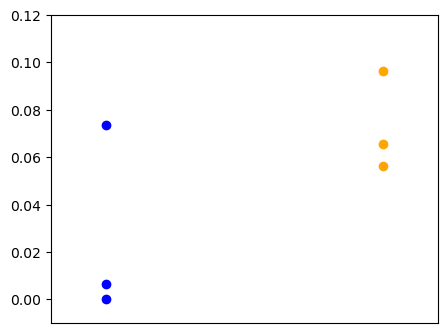

In [17]:
x_positions = [0, 1]
plt.figure(figsize=(5,4))
values_1, values_2 = sample_0, puff_0_puff_values

plt.scatter(x_positions[0], np.mean(values_1), color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[1], np.mean(values_2), color='orange', label='Safe' if i == 0 else "")

values_1, values_2 = sample_4, puff_4_puff_values
plt.scatter(x_positions[0], np.mean(values_1), color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[1], np.mean(values_2), color='orange', label='Safe' if i == 0 else "")

values_1, values_2 = sample_5, puff_5_puff_values
plt.scatter(x_positions[0], np.mean(values_1), color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[1], np.mean(values_2), color='orange', label='Safe' if i == 0 else "")
plt.xticks([])
plt.xlim(-0.2,1.2)
plt.ylim(-0.01, 0.12)
# plt.grid(True, axis='x', alpha=0.3 )
# plt.savefig('mean_puff_.svg')



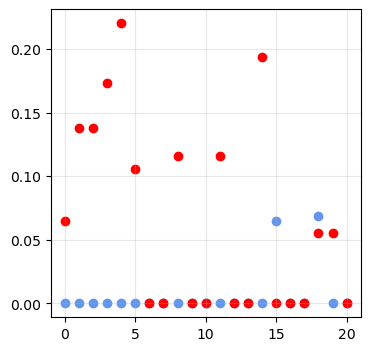

In [18]:
trials = np.arange(len(sample_4))
plt.figure(figsize=(4,4))
plt.scatter(trials, sample_4, color='cornflowerblue')
plt.scatter(trials, puff_4_puff_values, color='red')
plt.grid(True, alpha=0.3)
plt.savefig('smaller_puff_ses')

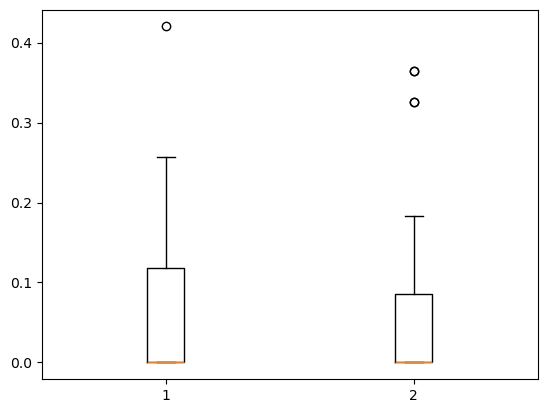

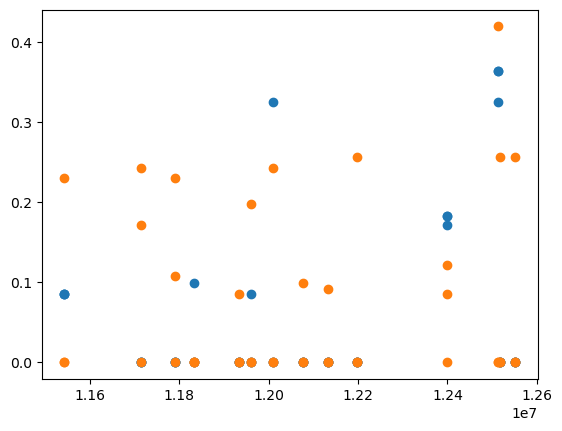

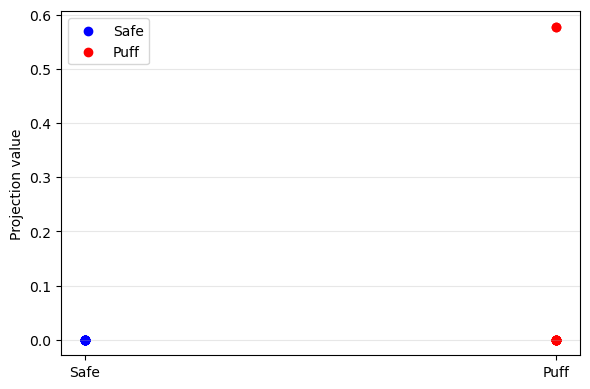

In [19]:

plt.boxplot([sample_0, puff_0_puff_values])
plt.savefig('new_box_puff_notgodd.svg')
plt.show()

plt.scatter(puff_0_puff_time, puff_0_puff_values)
plt.scatter(puff_0_puff_time, sample_0)
plt.show()

plot_comparison(sample_5, puff_5_puff_values, True, 1)

(array([10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([0.        , 0.05773503, 0.11547005, 0.17320508, 0.23094011,
        0.28867513, 0.34641016, 0.40414519, 0.46188022, 0.51961524,
        0.57735027]),
 <BarContainer object of 10 artists>)

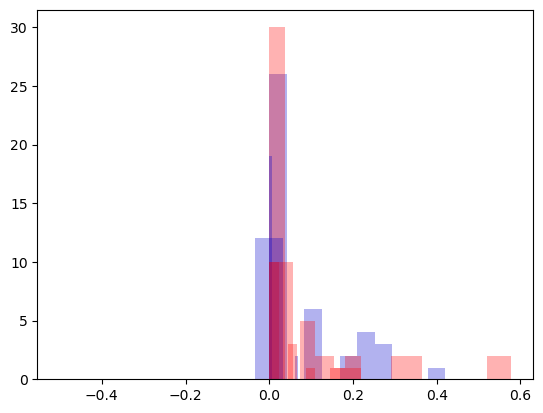

In [20]:
plt.figure()
safe_len = len(sample_0)
plt.hist(sample_0, color='mediumblue', alpha=0.3)
plt.hist(puff_0_puff_values, color='red', alpha=0.3)
plt.hist(sample_4, color='mediumblue', alpha=0.3)
plt.hist(puff_4_puff_values, color='red', alpha=0.3)
plt.hist(sample_5, color='mediumblue', alpha=0.3, bins=15)
plt.hist(puff_5_puff_values, color='red', alpha=0.3, bins=10)

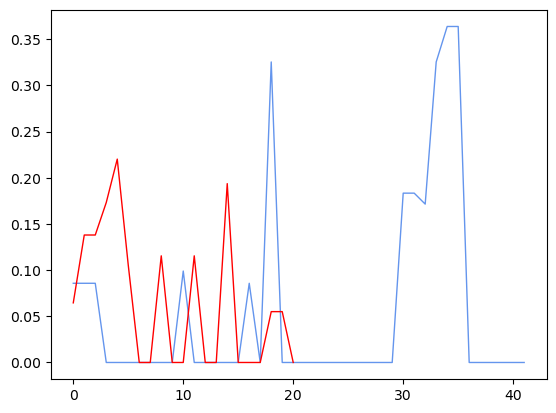

(array([1.529e+03, 3.900e+01, 5.900e+01, 2.000e+01, 5.000e+00, 1.000e+01,
        9.000e+00, 6.000e+00, 1.000e+00, 2.000e+00]),
 array([0.        , 0.0420084 , 0.08401681, 0.12602521, 0.16803361,
        0.21004201, 0.25205042, 0.29405882, 0.33606722, 0.37807562,
        0.42008403]),
 <BarContainer object of 10 artists>)

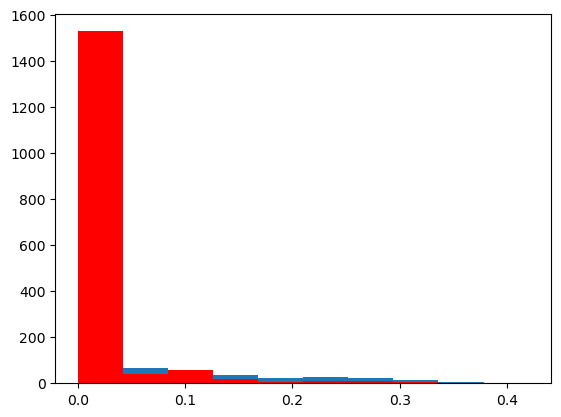

In [21]:
plt.plot(puff_0_puff_values, linewidth=1,  color='cornflowerblue')
plt.plot(data_puff_sample[2][1], linewidth=1,  color='red')
# plt.plot(data_puff_sample[0][0], linewidth=0.5,  color='green')
# plt.plot(data_puff_sample[0][1], linewidth=0.5,  color='orange')
plt.show()

plt.hist(data_puff_sample[1][0])
plt.hist(data_puff_sample[1][1], color='red')

In [22]:
# significance test
for i, (val_1, val_2) in enumerate(data_puff_sample):
    stat, p_value = mannwhitneyu(val_1, val_2, alternative='two-sided')
    if(i % 2 == 0):
        print(f"Mann Whitney U between Puff/Safe is: {stat}, with P-value: {p_value}")
    else:
        print(f"Mann Whitney U between Pre/Post is: {stat}, with P-value: {p_value}, \n")



Mann Whitney U between Puff/Safe is: 974.0, with P-value: 0.329024618224966
Mann Whitney U between Pre/Post is: 1497329.0, with P-value: 5.483546911834585e-08, 

Mann Whitney U between Puff/Safe is: 120.5, with P-value: 0.0022407167715110623
Mann Whitney U between Pre/Post is: 7846110.0, with P-value: 2.952503820577971e-05, 

Mann Whitney U between Puff/Safe is: 60.0, with P-value: 0.16582395411666384
Mann Whitney U between Pre/Post is: 3893322.0, with P-value: 0.026014659878880898, 



In [ ]:
n_sessions = int(len(data_puff_sample) / 2)

# significance test
for i, (val_1, val_2) in enumerate(data_puff_sample):
    stat, p_value = mannwhitneyu(val_1, val_2, alternative='two-sided')
    if(i % 2 == 0):
        print(f"Mann Whitney U between Puff/Safe is: {stat}, with P-value: {p_value}")
    else:
        print(f"Mann Whitney U between Pre/Post is: {stat}, with P-value: {p_value}, \n")

# scatter of all values
scatter_projection(data_puff_sample)

# comparison of values on left and right axes

fig, axes = plt.subplots(n_sessions, 2, figsize=(12, n_sessions*4))
for i, (values_1, values_2) in enumerate(data_puff_sample):
    row, col = divmod(i, 2)  
    safe_puff = (i % 2 == 0) 
    plot_comparison_subplots(values_1, values_2, safe_puff, 1, axes[row, col])

plt.tight_layout()
plt.show()

# difference plot
fig, axes = plt.subplots(n_sessions, 2, figsize=(12, n_sessions*4))
for i, (values_1, values_2) in enumerate(data_puff_sample):
    row, col = divmod(i, 2)  
    if(i % 2 == 0):
        scatter_differences_subplot(values_2, values_1, "Puff", "Safe", axes[row, col])
    else: 
        scatter_differences_subplot(values_2, values_1, "Post", "Pre", axes[row, col])

plt.tight_layout()
plt.show()

In [ ]:
data_safe_ = flatten([sample_4]) # sample_4, sample_5]) 
data_puff_ = flatten([puff_4_puff_values]) #, puff_4_puff_values, puff_5_puff_values])
plt.scatter(np.arange(len(data_safe_)), data_safe_, color='dodgerblue')
plt.scatter(np.arange(len(data_puff_)), data_puff_, color='r')
plt.grid(True, alpha=0.3)
plt.ylim(-0.02, 0.38)
# plt.savefig('more_puff_than_safe.svg')

In [ ]:
mean_puff = [np.mean(puff_0_puff_values), np.mean(puff_4_puff_values), np.mean(puff_5_puff_values)]
mean_safe = [np.mean(sample_0), np.mean(sample_4), np.mean(sample_5)]

mannwhitneyu(mean_puff, mean_safe, alternative='two-sided')


In [ ]:
from scipy.stats import zscore

safe_values_normalized = zscore(puff_0_safe_values), zscore(puff_4_safe_values), np.nan_to_num(zscore(puff_5_safe_values))
puff_values_normalized = zscore(puff_0_puff_values), zscore(puff_4_puff_values), np.nan_to_num(zscore(puff_5_puff_values))


values_1 = mean_safe
values_2 = mean_puff
plt.figure(figsize=(4, 4))

min_len = min(len(values_1), len(values_2))

plt.figure(figsize=(6, 4))
x_positions = [0, 1]

for i in range(min_len):
    plt.scatter(x_positions[0], values_1[i], color='blue', label='Safe' if i == 0 else "")
    plt.scatter(x_positions[1], values_2[i], color='red', label='Puff' if i == 0 else "")
    
plt.xticks(x_positions, ['Safe', 'Puff'])  # Set the x-tick labels to 'First Half' and 'Second Half'
plt.ylabel('Projection value')
# plt.title('Projection values for Safe and Puff runs')
# plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('mean_puff_safe.svg')
plt.show()



# With bigger window

In [23]:
with open("results_rat_11_puff_bigger_70-30_56101213.pkl", "rb") as pkl_file:
    rat11_puff_bigger = pickle.load(pkl_file)

with open("results_rat_10_puff_bigger.pkl", "rb") as pkl_file:
    rat10_puff_bigger = pickle.load(pkl_file)

with open("results_rat_8_puff_bigger.pkl" , "rb") as pkl_file:
    rat8_puff_bigger = pickle.load(pkl_file)

In [24]:
big_0_puff_values = np.nan_to_num(rat11_puff_bigger[0]['puff_results']['values'])
big_0_puff_time = rat11_puff_bigger[0]['puff_results']['time_points']

big_0_safe_values = np.nan_to_num(rat11_puff_bigger[0]['safe_results']['values'])
big_0_safe_time = rat11_puff_bigger[0]['safe_results']['time_points']

big_0_pre_values = np.nan_to_num(rat11_puff_bigger[0]['pre_results']['values'])
big_0_pre_time = rat11_puff_bigger[0]['pre_results']['time_points']

big_0_post_values = np.nan_to_num(rat11_puff_bigger[0]['post_results']['values'])
big_0_post_time = rat11_puff_bigger[0]['post_results']['time_points']

big_1_puff_values = np.nan_to_num(rat11_puff_bigger[6]['puff_results']['values'])
big_1_puff_time = rat11_puff_bigger[6]['puff_results']['time_points']

big_1_safe_values = np.nan_to_num(rat11_puff_bigger[6]['safe_results']['values'])
big_1_safe_time = rat11_puff_bigger[6]['safe_results']['time_points']

big_1_pre_values = np.nan_to_num(rat11_puff_bigger[6]['pre_results']['values'])
big_1_pre_time = rat11_puff_bigger[6]['pre_results']['time_points']

big_1_post_values = np.nan_to_num(rat11_puff_bigger[6]['post_results']['values'])
big_1_post_time = rat11_puff_bigger[6]['post_results']['time_points']

big_2_puff_values = np.nan_to_num(rat10_puff_bigger[5]['puff_results']['values'])
big_2_puff_time = rat10_puff_bigger[5]['puff_results']['time_points']

big_2_safe_values = np.nan_to_num(rat10_puff_bigger[5]['safe_results']['values'])
big_2_safe_time = rat10_puff_bigger[5]['safe_results']['time_points']

big_2_pre_values = np.nan_to_num(rat10_puff_bigger[5]['pre_results']['values'])
big_2_pre_time = rat10_puff_bigger[5]['pre_results']['time_points']

big_2_post_values = np.nan_to_num(rat10_puff_bigger[5]['post_results']['values'])
big_2_post_time = rat10_puff_bigger[5]['post_results']['time_points']

In [25]:
data_big = [
    [big_0_safe_values, big_0_puff_values], 
    [big_1_safe_values, big_1_puff_values],
    [big_2_safe_values, big_2_puff_values]]


In [26]:
sample_0_b = rng.choice(big_0_safe_values, len(big_0_puff_values), replace=False)
sample_1_b = rng.choice(big_1_safe_values, len(big_1_puff_values), replace=False)
sample_2_b = rng.choice(big_2_safe_values, len(big_2_puff_values), replace=False)

data_big_sample = [
    [sample_0_b, big_0_puff_values], 
    [sample_1_b, big_1_puff_values], 
    [sample_2_b, big_0_puff_values]]

Mann Whitney U between Puff/Safe is: 48205.0, with P-value: 5.597794138762018e-06
Mann Whitney U between Pre/Post is: 7595.0, with P-value: 2.5041301383206372e-11, 

Mann Whitney U between Puff/Safe is: 10497.0, with P-value: 0.0008991854381565764


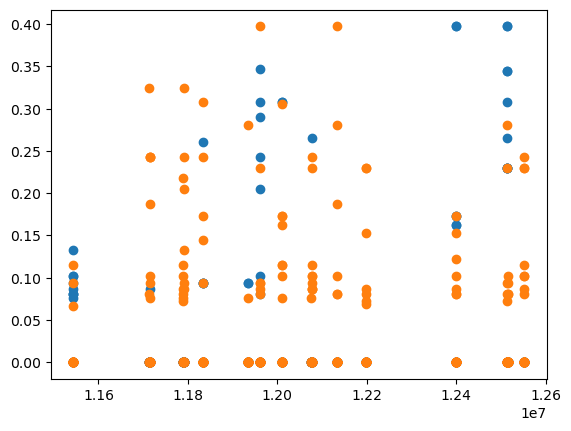

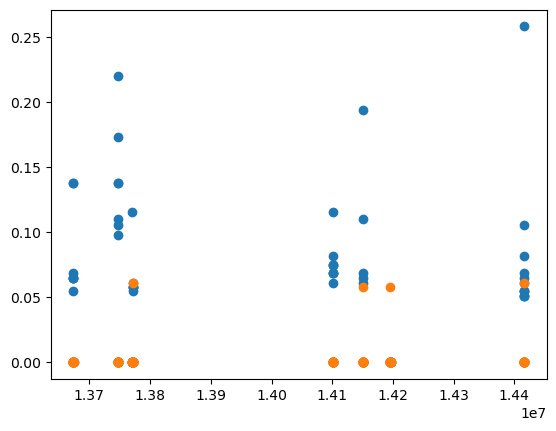

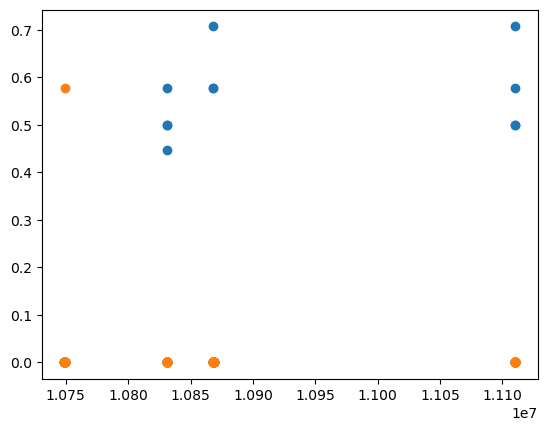

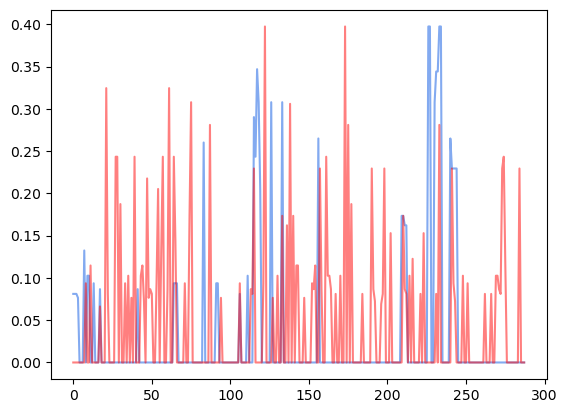

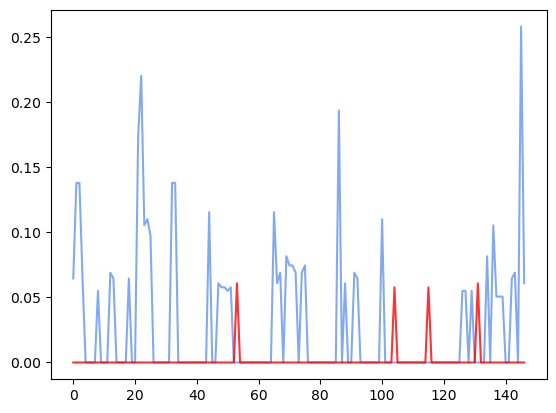

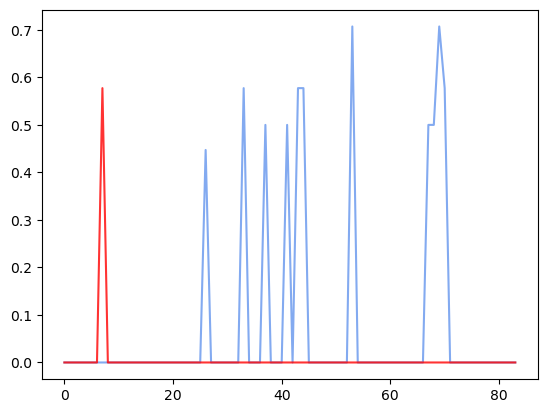

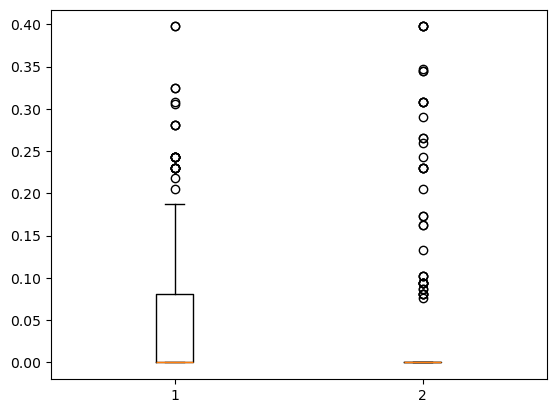

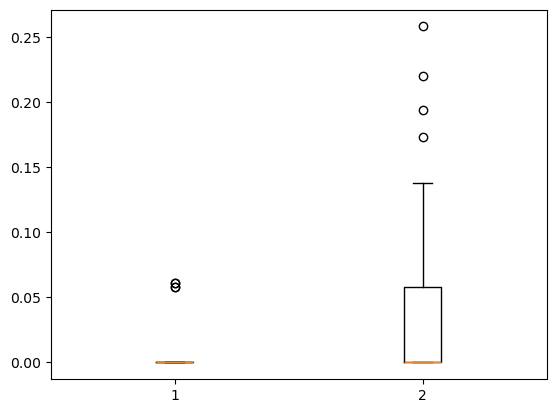

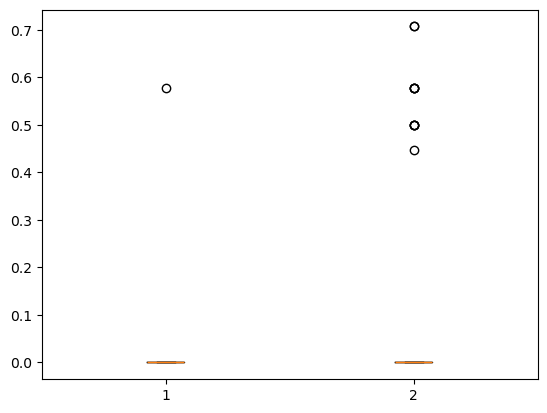

In [27]:
n_sessions = int(len(data_big) / 2)

# significance test
for i, (val_1, val_2) in enumerate(data_big_sample):
    stat, p_value = mannwhitneyu(val_1, val_2, alternative='two-sided')
    if(i % 2 == 0):
        print(f"Mann Whitney U between Puff/Safe is: {stat}, with P-value: {p_value}")
    else:
        print(f"Mann Whitney U between Pre/Post is: {stat}, with P-value: {p_value}, \n")

# # scatter of all values
plt.scatter(big_0_puff_time, big_0_puff_values)
plt.scatter(big_0_puff_time, sample_0_b)
plt.show()

plt.scatter(big_1_puff_time, big_1_puff_values)
plt.scatter(big_1_puff_time, sample_1_b)
plt.show()

plt.scatter(big_2_puff_time, big_2_puff_values)
plt.scatter(big_2_puff_time, sample_2_b)
plt.show()

plt.plot(big_0_puff_values, color='cornflowerblue', alpha=0.8)
plt.plot(sample_0_b, color='red', alpha=0.5)
plt.show()

plt.plot(big_1_puff_values, color='cornflowerblue', alpha=0.8)
plt.plot(sample_1_b,  color='red', alpha=0.8)
plt.show()

plt.plot(big_2_puff_values, color='cornflowerblue', alpha=0.8)
plt.plot(sample_2_b,  color='red', alpha=0.8)
plt.show()

plt.boxplot([sample_0_b, big_0_puff_values])
plt.show()

plt.boxplot([sample_1_b, big_1_puff_values])
plt.show()

plt.boxplot([sample_2_b, big_2_puff_values])
plt.show()


# # comparison of values on left and right axes

# fig, axes = plt.subplots(n_sessions, 2, figsize=(12, n_sessions*4))
# for i, (values_1, values_2) in enumerate(data_big):
#     row, col = divmod(i, 2)  
#     safe_puff = (i % 2 == 0) 
#     plot_comparison_subplots(values_1, values_2, safe_puff, 1, axes[row, col])

# plt.tight_layout()
# plt.show()

# # difference plot
# fig, axes = plt.subplots(n_sessions, 2, figsize=(12, n_sessions*4))
# for i, (values_1, values_2) in enumerate(data_big):
#     row, col = divmod(i, 2)  
#     if(i % 2 == 0):
#         scatter_differences_subplot(values_2, values_1, "Puff", "Safe", axes[row, col])
#     else: 
#         scatter_differences_subplot(values_2, values_1, "Post", "Pre", axes[row, col])

# plt.tight_layout()
# plt.show()
# plt.figure()
# data_safe_big = flatten([sample_0_b, sample_1_b, sample_2_b])
# data_puff_big = flatten([big_0_puff_values, big_1_puff_values, big_2_puff_values])
# plt.scatter(np.arange(len(data_safe_big)), data_safe_big, color='b')
# plt.scatter(np.arange(len(data_puff_big)), data_puff_big, color='r')
# plt.grid(True, alpha=0.3)


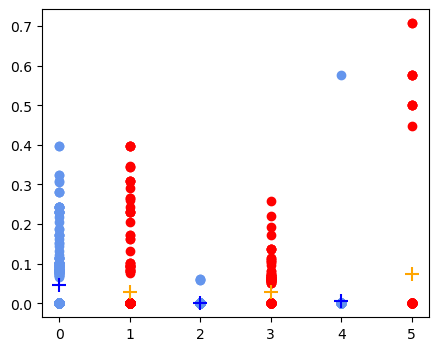

In [28]:
x_positions = [0, 1, 2, 3, 4, 5]
plt.figure(figsize=(5,4))
values_1, values_2 = sample_0_b, big_0_puff_values
for i in range(len(values_1)):
    plt.scatter(x_positions[0], values_1[i], color='cornflowerblue', label='Safe' if i == 0 else "")
    plt.scatter(x_positions[1], values_2[i], color='red', label='Puff' if i == 0 else "")
plt.scatter(x_positions[0], np.mean(values_1), marker='+', s=100, color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[1], np.mean(values_2), marker='+', s=100, color='orange', label='Safe' if i == 0 else "")

values_1, values_2 = sample_1_b, big_1_puff_values
for i in range(len(values_1)):
    plt.scatter(x_positions[2], values_1[i], color='cornflowerblue', label='Safe' if i == 0 else "")
    plt.scatter(x_positions[3], values_2[i], color='red', label='Puff' if i == 0 else "")
plt.scatter(x_positions[2], np.mean(values_1), marker='+', s=100, color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[3], np.mean(values_2), marker='+', s=100, color='orange', label='Safe' if i == 0 else "")

values_1, values_2 = sample_2_b, big_2_puff_values
for i in range(len(values_1)):
    plt.scatter(x_positions[4], values_1[i], color='cornflowerblue', label='Safe' if i == 0 else "")
    plt.scatter(x_positions[5], values_2[i], color='red', label='Puff' if i == 0 else "")
plt.scatter(x_positions[4], np.mean(values_1), marker='+', s=100, color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[5], np.mean(values_2), marker='+', s=100, color='orange', label='Safe' if i == 0 else "")

# plt.savefig('mean_big_puff.svg')

(-0.01, 0.12)

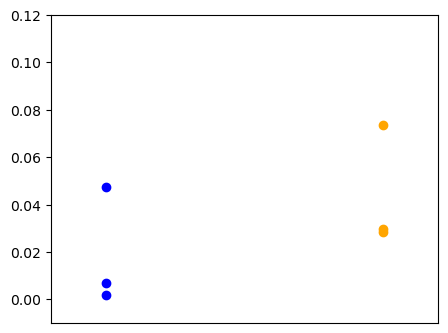

In [29]:
x_positions = [0, 1]
plt.figure(figsize=(5,4))
values_1, values_2 = sample_0_b, big_0_puff_values

plt.scatter(x_positions[0], np.mean(values_1), color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[1], np.mean(values_2), color='orange', label='Safe' if i == 0 else "")

values_1, values_2 = sample_1_b, big_1_puff_values
plt.scatter(x_positions[0], np.mean(values_1), color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[1], np.mean(values_2), color='orange', label='Safe' if i == 0 else "")

values_1, values_2 = sample_2_b, big_2_puff_values
plt.scatter(x_positions[0], np.mean(values_1), color='blue', label='Safe' if i == 0 else "")
plt.scatter(x_positions[1], np.mean(values_2), color='orange', label='Safe' if i == 0 else "")
plt.xticks([])
plt.xlim(-0.2,1.2)
plt.ylim(-0.01, 0.12)
# plt.grid(True, axis='x', alpha=0.3 )
# plt.savefig('mean_puff_big.svg')



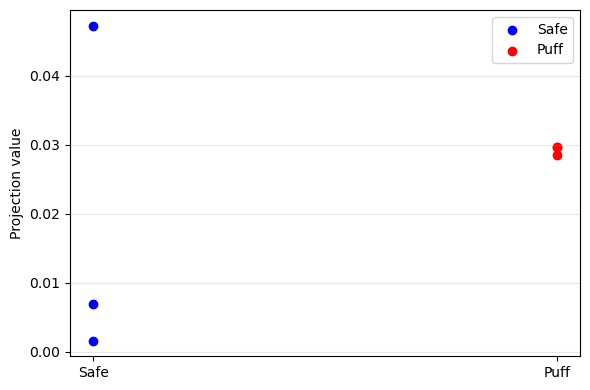

MannwhitneyuResult(statistic=3.0, pvalue=0.6579050194284821)

In [30]:
mean_safe_big = []
mean_puff_big = []
for (i, j) in data_big_sample:
    mean_safe_big.append(np.mean(i))
    mean_puff_big.append(np.mean(j))

plot_comparison(mean_safe_big, mean_puff_big, True, 1)

mannwhitneyu(mean_safe_big, mean_puff_big, alternative='two-sided')

In [ ]:
# from scipy.stats import mannwhitneyu, ks_2samp, iqr
# from scipy.stats import rankdata
# from itertools import product
# from scipy.stats import gaussian_kde

# def cliffs_delta(group1, group2):
#     n1 = len(group1)
#     n2 = len(group2)
#     comparisons = list(product(group1, group2))
#     more = sum(1 for x, y in comparisons if x > y)
#     less = sum(1 for x, y in comparisons if x < y)
#     delta = (more - less) / (n1 * n2)
#     return delta

# for n, (i, j) in enumerate(data_puff_results):
#     if n % 2 != 0:

#         pre_sleep, post_sleep = i, j
    
#         # Mann-Whitney U Test
#         mw_stat, mw_p = mannwhitneyu(pre_sleep, post_sleep, alternative="two-sided")
#         print(f"Mann-Whitney U Test: U={mw_stat}, p={mw_p}")
        
#         # Kolmogorov-Smirnov Test
#         ks_stat, ks_p = ks_2samp(pre_sleep, post_sleep)
#         print(f"Kolmogorov-Smirnov Test: KS Statistic={ks_stat}, p={ks_p}")
        
#         # Effect Size (Rank-Biserial Correlation)
#         rank_diff = rankdata(np.concatenate([pre_sleep, post_sleep]))[:len(pre_sleep)].mean() - \
#                     rankdata(np.concatenate([pre_sleep, post_sleep]))[len(pre_sleep):].mean()
#         rank_biserial_corr = rank_diff / len(pre_sleep)
#         print(f"Rank-Biserial Correlation (Effect Size): {rank_biserial_corr}")
    
#         delta = cliffs_delta(pre_sleep, post_sleep)
#         print(f"Cliff's Delta: {delta}")
    
#         x_pre = np.linspace(min(pre_sleep), max(pre_sleep), 1000)
#         x_post = np.linspace(min(post_sleep), max(post_sleep), 1000)
        
#         kde_pre = gaussian_kde(pre_sleep)
#         kde_post = gaussian_kde(post_sleep)
        
#         plt.figure(figsize=(6, 4))
#         plt.fill_between(x_pre, kde_pre(x_pre), color='mediumblue', alpha=0.5, label='Pre-sleep Ripples')
#         plt.fill_between(x_post, kde_post(x_post), color='red', alpha=0.5, label='Post-sleep Ripples')
        
#         plt.title("Kernel Density Estimation (KDE) of Pre- and Post-sleep Ripples", fontsize=14)
#         plt.xlabel("Projection Value", fontsize=12)
#         plt.ylabel("Density", fontsize=12)
#         plt.legend()
#         plt.show()




# With MI values

In [ ]:
with open("results_rat_11_puff_seq_2.pkl", "rb") as pkl_file:
    rat11_seq = pickle.load(pkl_file)

with open("results_rat_10_puff_seq.pkl", "rb") as pkl_file:
    rat10_seq = pickle.load(pkl_file)

with open("results_rat_8_puff_seq.pkl" , "rb") as pkl_file:
    rat8_seq = pickle.load(pkl_file)

In [ ]:
data_seq = [
    [seq_0_safe_values, seq_0_puff_values], 
    [seq_0_pre_values, seq_0_post_values], 
    [seq_1_safe_values, seq_1_puff_values],
    [seq_1_pre_values, seq_1_post_values],
    [seq_2_safe_values, seq_2_puff_values], 
    [seq_2_pre_values, seq_2_post_values], 
    [seq_3_safe_values, seq_3_puff_values],
    [seq_3_pre_values, seq_3_post_values],
    [seq_4_safe_values, seq_4_puff_values], 
    [seq_4_pre_values, seq_4_post_values], 
    [seq_5_safe_values, seq_5_puff_values], 
    [seq_5_pre_values, seq_5_post_values],
    [seq_6_safe_values, seq_6_puff_values], 
    [seq_6_pre_values, seq_6_post_values]]

data_seq_results = [
    [seq_0_safe_values, seq_0_puff_values], 
    [seq_0_pre_values, seq_0_post_values],
    [seq_3_safe_values, seq_3_puff_values],
    [seq_3_pre_values, seq_3_post_values],
    [seq_4_safe_values, seq_4_puff_values], 
    [seq_4_pre_values, seq_4_post_values], 
    [seq_5_safe_values, seq_5_puff_values], 
    [seq_5_pre_values, seq_5_post_values],
    [seq_6_safe_values, seq_6_puff_values], 
    [seq_6_pre_values, seq_6_post_values]]

sample_seq_0 = rng.choice(seq_0_safe_values, len(seq_0_puff_values), replace=False)
sample_seq_3 = rng.choice(seq_3_safe_values, len(seq_3_puff_values), replace=False)
sample_seq_4 = rng.choice(seq_4_safe_values, len(seq_4_puff_values), replace=False)
sample_seq_5 = rng.choice(seq_5_safe_values, len(seq_5_puff_values), replace=False)
sample_seq_6 = rng.choice(seq_6_safe_values, len(seq_6_puff_values), replace=False)

data_seq_results = [
    [sample_seq_0, seq_0_puff_values], 
    [seq_0_pre_values, seq_0_post_values],
    [sample_seq_3, seq_3_puff_values],
    [seq_3_pre_values, seq_3_post_values],
    [sample_seq_4, seq_4_puff_values], 
    [seq_4_pre_values, seq_4_post_values], 
    [sample_seq_5, seq_5_puff_values], 
    [seq_5_pre_values, seq_5_post_values],
    [sample_seq_6, seq_6_puff_values], 
    [seq_6_pre_values, seq_6_post_values]]

In [ ]:
n_sessions = int(len(data_seq) / 2)

# significance test
for i, (val_1, val_2) in enumerate(data_seq_results):
    stat, p_value = mannwhitneyu(val_1, val_2, alternative='two-sided')
    if(i % 2 == 0):
        print(f"Mann Whitney U between Puff/Safe is: {stat}, with P-value: {p_value}")
    else:
        print(f"Mann Whitney U between Pre/Post is: {stat}, with P-value: {p_value}, \n")

# scatter of all values
scatter_projection(data_seq_results)

data_safe_ = flatten([sample_seq_0, sample_seq_3, sample_seq_4, sample_seq_5, sample_seq_6]) # sample_4, sample_5]) 
data_puff_ = flatten([seq_0_puff_values, seq_3_puff_values, seq_4_puff_values, seq_5_puff_values, seq_6_puff_values]) #, puff_4_puff_values, puff_5_puff_values])
plt.scatter(np.arange(len(data_safe_)), data_safe_, color='dodgerblue')
plt.scatter(np.arange(len(data_puff_)), data_puff_, color='r')
plt.grid(True, alpha=0.3)
plt.ylim(-0.02, 0.38)
# plt.savefig('more_puff_than_safe.svg')

# # comparison of values on left and right axes

# fig, axes = plt.subplots(n_sessions, 2, figsize=(12, n_sessions*4))
# for i, (values_1, values_2) in enumerate(data_seq):
#     row, col = divmod(i, 2)  
#     safe_puff = (i % 2 == 0) 
#     plot_comparison_subplots(values_1, values_2, safe_puff, 1, axes[row, col])

# plt.tight_layout()
# plt.show()

# # difference plot
# fig, axes = plt.subplots(n_sessions, 2, figsize=(12, n_sessions*4))
# for i, (values_1, values_2) in enumerate(data_seq):
#     row, col = divmod(i, 2)  
#     if(i % 2 == 0):
#         scatter_differences_subplot(values_2, values_1, "Puff", "Safe", axes[row, col])
#     else: 
#         scatter_differences_subplot(values_2, values_1, "Post", "Pre", axes[row, col])

# plt.tight_layout()
# plt.show()


In [ ]:
# GET PUFF VARIABLES
# RAT 11

seq_0_puff_values = np.nan_to_num(rat11_seq[0]['puff_results']['values'])
seq_0_puff_time = rat11_seq[0]['puff_results']['time_points']

seq_0_safe_values = np.nan_to_num(rat11_seq[0]['safe_results']['values'])
seq_0_safe_time = rat11_seq[0]['safe_results']['time_points']

seq_0_pre_values = np.nan_to_num(rat11_seq[0]['pre_results']['values'])
seq_0_pre_time = rat11_seq[0]['pre_results']['time_points']

seq_0_post_values = np.nan_to_num(rat11_seq[0]['post_results']['values'])
seq_0_post_time = rat11_seq[0]['post_results']['time_points']

seq_1_puff_values = np.nan_to_num(rat11_seq[1]['puff_results']['values'])
seq_1_puff_time = rat11_seq[1]['puff_results']['time_points']

seq_1_safe_values = np.nan_to_num(rat11_seq[1]['safe_results']['values'])
seq_1_safe_time = np.nan_to_num(rat11_seq[1]['safe_results']['time_points'])

seq_1_pre_values = np.nan_to_num(rat11_seq[1]['pre_results']['values'])
seq_1_pre_time = np.nan_to_num(rat11_seq[1]['pre_results']['time_points'])

seq_1_post_values = np.nan_to_num(rat11_seq[1]['post_results']['values'])
seq_1_post_time = rat11_seq[1]['post_results']['time_points']

seq_2_puff_values = np.nan_to_num(rat11_seq[4]['puff_results']['values'])
seq_2_puff_time = rat11_seq[4]['puff_results']['time_points']

seq_2_safe_values = np.nan_to_num(rat11_seq[4]['safe_results']['values'])
seq_2_safe_time = rat11_seq[4]['safe_results']['time_points']

seq_2_pre_values = np.nan_to_num(rat11_seq[4]['pre_results']['values'])
seq_2_pre_time = rat11_seq[4]['pre_results']['time_points']

seq_2_post_values = np.nan_to_num(rat11_seq[4]['post_results']['values'])
seq_2_post_time = rat11_seq[4]['post_results']['time_points']

seq_3_puff_values = np.nan_to_num(rat11_seq[5]['puff_results']['values'])
seq_3_puff_time = rat11_seq[5]['puff_results']['time_points']

seq_3_safe_values = np.nan_to_num(rat11_seq[5]['safe_results']['values'])
seq_3_safe_time = np.nan_to_num(rat11_seq[5]['safe_results']['time_points'])

seq_3_pre_values = np.nan_to_num(rat11_seq[5]['pre_results']['values'])
seq_3_pre_time = np.nan_to_num(rat11_seq[5]['pre_results']['time_points'])

seq_3_post_values = np.nan_to_num(rat11_seq[5]['post_results']['values'])
seq_3_post_time = rat11_seq[5]['post_results']['time_points']

seq_4_puff_values = np.nan_to_num(rat11_seq[6]['puff_results']['values'])
seq_4_puff_time = rat11_seq[6]['puff_results']['time_points']

seq_4_safe_values = np.nan_to_num(rat11_seq[6]['safe_results']['values'])
seq_4_safe_time = rat11_seq[6]['safe_results']['time_points']

seq_4_pre_values = np.nan_to_num(rat11_seq[6]['pre_results']['values'])
seq_4_pre_time = rat11_seq[6]['pre_results']['time_points']

seq_4_post_values = np.nan_to_num(rat11_seq[6]['post_results']['values'])
seq_4_post_time = rat11_seq[6]['post_results']['time_points']


# RAT 10

seq_5_puff_values = np.nan_to_num(rat10_seq[5]['puff_results']['values'])
seq_5_puff_time = rat10_seq[5]['puff_results']['time_points']

seq_5_safe_values = np.nan_to_num(rat10_seq[5]['safe_results']['values'])
seq_5_safe_time = rat10_seq[5]['safe_results']['time_points']

seq_5_pre_values = np.nan_to_num(rat10_seq[5]['pre_results']['values'])
seq_5_pre_time = rat10_seq[5]['pre_results']['time_points']

seq_5_post_values = np.nan_to_num(rat10_seq[5]['post_results']['values'])
seq_5_post_time = rat10_seq[5]['post_results']['time_points']

# RAT 08

seq_6_puff_values = np.nan_to_num(rat8_seq[0]['puff_results']['values'])
seq_6_puff_time = rat8_seq[0]['puff_results']['time_points']

seq_6_safe_values = np.nan_to_num(rat8_seq[0]['safe_results']['values'])
seq_6_safe_time = rat8_seq[0]['safe_results']['time_points']

seq_6_pre_values = np.nan_to_num(rat8_seq[0]['pre_results']['values'])
seq_6_pre_time = rat8_seq[0]['pre_results']['time_points']

seq_6_post_values = np.nan_to_num(rat8_seq[0]['post_results']['values'])
seq_6_post_time = rat8_seq[0]['post_results']['time_points']




# Reactivation SWRS

In [32]:
data_puff_ripples = [
    [puff_0_pre_values, puff_0_post_values], 
    [puff_4_pre_values, puff_4_post_values],
    [puff_5_pre_values, puff_5_post_values]]

sample_0 = rng.choice(puff_0_pre_values, len(puff_0_post_values), replace=False)
sample_4 = rng.choice(puff_4_post_values, len(puff_4_pre_values), replace=False)
sample_5 = rng.choice(puff_5_post_values, len(puff_5_pre_values), replace=False)


ripples_sample = [
    [sample_0, puff_0_post_values], 
    [puff_4_pre_values, sample_4],
    [puff_5_pre_values, sample_5]]

# significance test
for i, (val_1, val_2) in enumerate(ripples_sample):
    stat, p_value = mannwhitneyu(val_1, val_2, alternative='two-sided')
    if(i % 2 == 0):
        print(f"Mann Whitney U between Puff/Safe is: {stat}, with P-value: {p_value}")
    else:
        print(f"Mann Whitney U between Pre/Post is: {stat}, with P-value: {p_value}, \n")

Mann Whitney U between Puff/Safe is: 1502839.0, with P-value: 9.180204398132478e-09
Mann Whitney U between Pre/Post is: 7807898.0, with P-value: 0.00037115333348026867, 

Mann Whitney U between Puff/Safe is: 3893370.0, with P-value: 0.025837355103740193


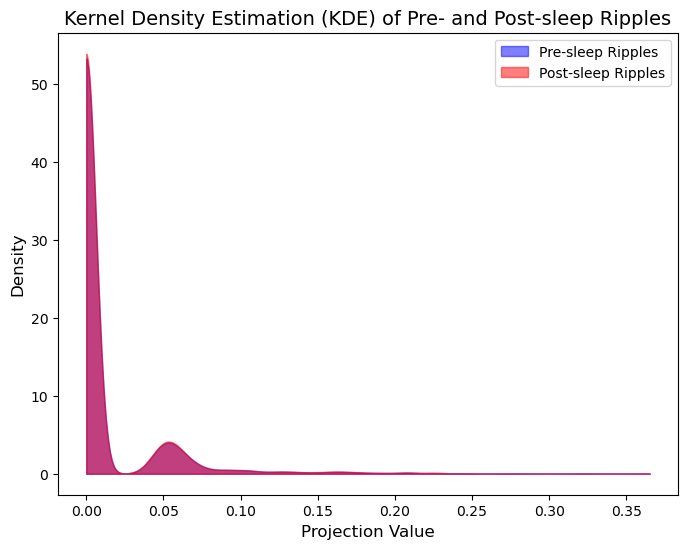

In [12]:

from scipy.stats import gaussian_kde
pre_sleep, post_sleep = sample_4, puff_4_post_values

# Generate density data
x_pre = np.linspace(min(pre_sleep), max(pre_sleep), 1000)
x_post = np.linspace(min(post_sleep), max(post_sleep), 1000)

kde_pre = gaussian_kde(pre_sleep)
kde_post = gaussian_kde(post_sleep)

plt.figure(figsize=(8, 6))
plt.fill_between(x_pre, kde_pre(x_pre), color='blue', alpha=0.5, label='Pre-sleep Ripples')
plt.fill_between(x_post, kde_post(x_post), color='red', alpha=0.5, label='Post-sleep Ripples')

plt.title("Kernel Density Estimation (KDE) of Pre- and Post-sleep Ripples", fontsize=14)
plt.xlabel("Projection Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()

(array([3.667e+03, 4.600e+02, 8.300e+01, 3.700e+01, 3.700e+01, 2.000e+01,
        1.300e+01, 2.000e+00, 1.000e+00, 1.000e+00]),
 array([0.        , 0.03651484, 0.07302967, 0.10954451, 0.14605935,
        0.18257419, 0.21908902, 0.25560386, 0.2921187 , 0.32863353,
        0.36514837]),
 <BarContainer object of 10 artists>)

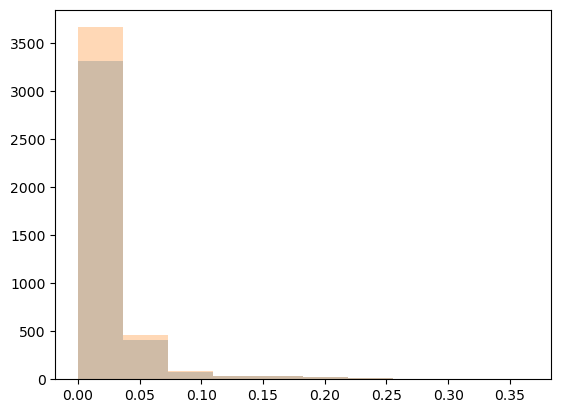

In [13]:
plt.hist(pre_sleep, alpha=0.3)
plt.hist(post_sleep, alpha=0.3)

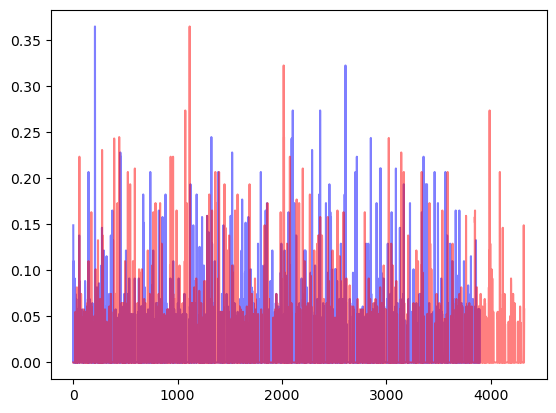

In [14]:
plt.plot(pre_sleep, color='blue', alpha=0.5)
plt.plot(post_sleep, color='red', alpha=0.5)

In [35]:
idxs_0_p = np.nonzero(sample_0)
idxs_0_p = np.nonzero(puff_0_pre_values)
# vals_0_p = sample_0[idxs_0_p]
vals_0_p = puff_0_pre_values[idxs_0_p]

idxs_0_po = np.nonzero(puff_0_post_values)
vals_0_po = puff_0_post_values[idxs_0_po]

# idxs_4_po = np.nonzero(sample_4)
idxs_4_po = np.nonzero(puff_4_post_values)
# vals_4_po = sample_4[idxs_4_po]
vals_4_po = puff_4_post_values[idxs_4_po]

idxs_4_pr = np.nonzero(puff_4_pre_values)
vals_4_pr = puff_4_pre_values[idxs_4_pr]

idxs_5_po = np.nonzero(sample_5)
idxs_5_po = np.nonzero(puff_5_post_values)
vals_5_po = puff_5_post_values[idxs_5_po]
# vals_5_po = sample_5[idxs_5_po]

idxs_5_pr = np.nonzero(puff_5_pre_values)
vals_5_pr = puff_5_pre_values[idxs_5_pr]

ripples_nonzero = [
    [vals_0_p, vals_0_po],
    [vals_4_pr, vals_4_po],
    [vals_5_pr, vals_5_po]]

for i, (val_1, val_2) in enumerate(ripples_nonzero):
    stat, p_value = mannwhitneyu(val_1, val_2, alternative='two-sided')
    if(i % 2 == 0):
        print(f"Mann Whitney U between Puff/Safe is: {stat}, with P-value: {p_value}")
    else:
        print(f"Mann Whitney U between Pre/Post is: {stat}, with P-value: {p_value}, \n")

from scipy.stats import ks_2samp

# ks_statistic, p_value = ks_2samp(pre_sleep, post_sleep)

for i, (val_1, val_2) in enumerate(ripples_nonzero):
    ks_stat, p_value = ks_2samp(val_1, val_2)
    print(f"KSbetween Pre/Post is: {stat}, with P-value: {p_value}, \n")

Mann Whitney U between Puff/Safe is: 41757.0, with P-value: 0.04771670568548823
Mann Whitney U between Pre/Post is: 243289.5, with P-value: 0.1638645149827317, 

Mann Whitney U between Puff/Safe is: 7976.5, with P-value: 0.9584866407201703
KSbetween Pre/Post is: 7976.5, with P-value: 3.892314728591736e-05, 

KSbetween Pre/Post is: 7976.5, with P-value: 0.0878062774390056, 

KSbetween Pre/Post is: 7976.5, with P-value: 0.9849243780834165, 



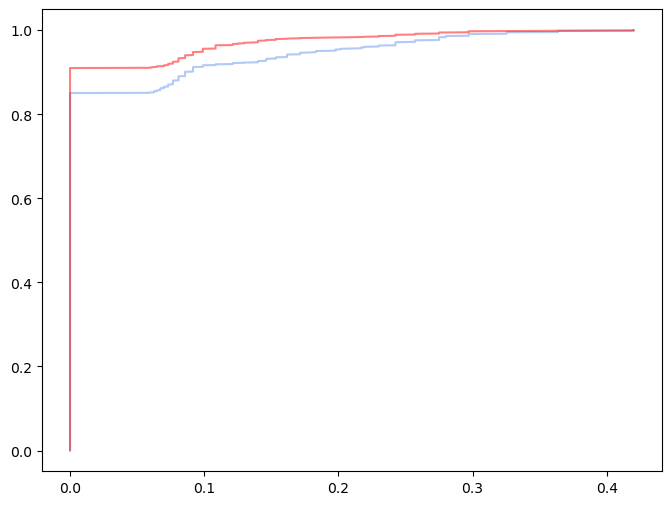

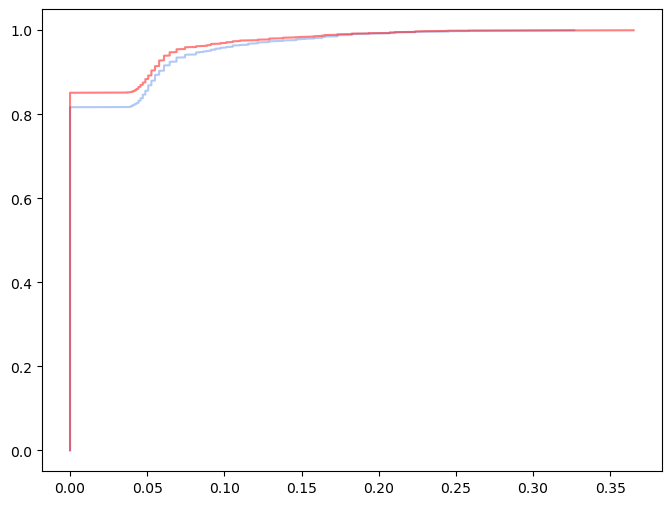

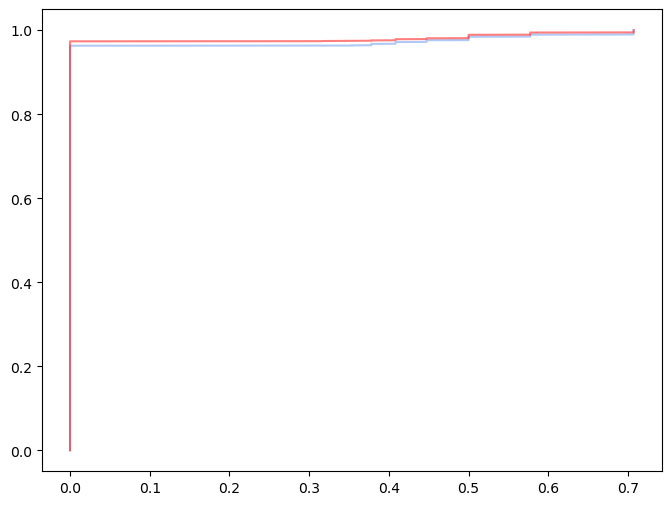

In [36]:
# import matplotlib.pyplot as plt
# import numpy as np

# Example: CDFs for pre-sleep and post-sleep
def plot_cdf(data, label, color):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cdf, label=label, color=color, alpha=0.5)

plt.figure(figsize=(8, 6))
plot_cdf(sample_0_p, "Pre-sleep", "cornflowerblue")
plot_cdf(puff_0_post_values, "Post-sleep (Left)", "red")
# plt.title("CDF Comparison for Left Graph")
# plt.legend()
plt.savefig('cdf_ripples_i.svg')
plt.show()

plt.figure(figsize=(8, 6))
plot_cdf(puff_4_pre_values, "Pre-sleep (Left)", "cornflowerblue")
plot_cdf(sample_4_p, "Post-sleep (Left)", "red")
# plt.title("CDF Comparison for Left Graph")
plt.savefig('cdf_ripples_ii.svg')
# plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plot_cdf(puff_5_pre_values, "Pre-sleep (Left)", "cornflowerblue")
plot_cdf(sample_5_p, "Post-sleep (Left)", "red")
# plt.title("CDF Comparison for Left Graph")
plt.savefig('cdf_ripples_iii.svg')
# plt.legend()
plt.show()

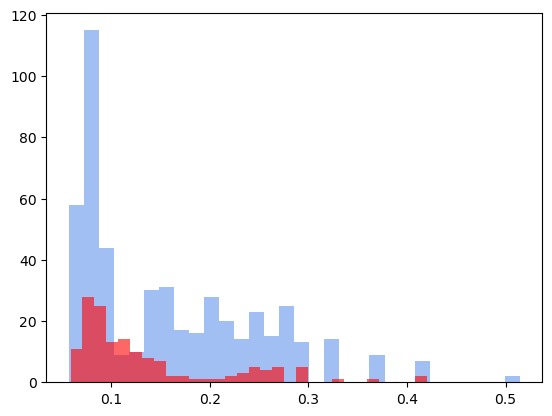

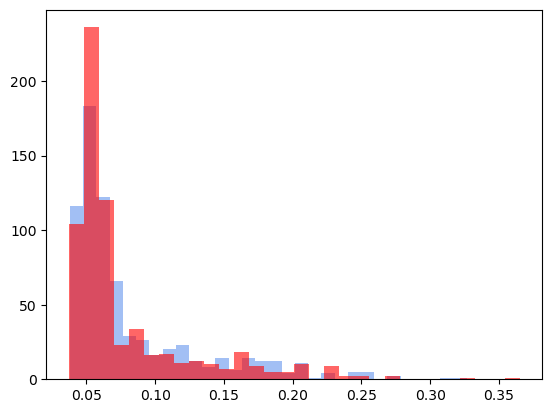

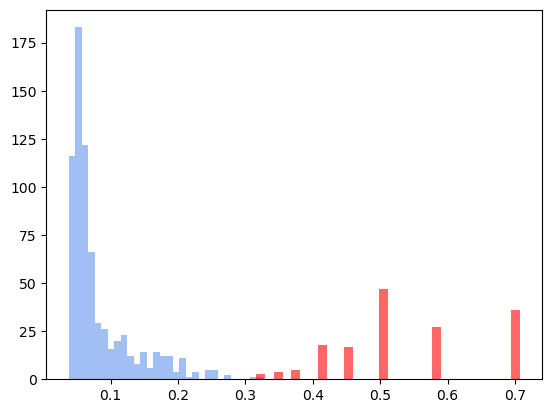

In [37]:
plt.hist(vals_0_p, bins=30,color='cornflowerblue', alpha=0.6)
plt.hist(vals_0_po, bins=30,  color='red',alpha=0.6)
plt.savefig('hist_rip_1.svg')
plt.show()

plt.hist(vals_4_pr, bins=30,color='cornflowerblue', alpha=0.6)
plt.hist(vals_4_po, bins=30,  color='red',alpha=0.6)
plt.savefig('hist_rip_2.svg')
plt.show()

plt.hist(vals_4_pr, bins=30,color='cornflowerblue', alpha=0.6)
plt.hist(vals_5_po, bins=30,  color='red',alpha=0.6)
plt.savefig('hist_rip_3.svg')
plt.show()

In [143]:
pre = [puff_0_pre_values, puff_4_pre_values, puff_5_pre_values]
post = [puff_5_post_values, puff_4_post_values , puff_0_post_values]

pre_len = np.arange(len(pre))

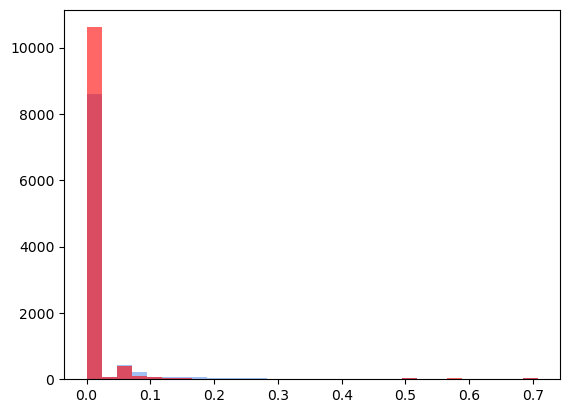

In [203]:
plt.hist(flatten(pre), color = 'cornflowerblue', alpha=0.6, bins=30)
plt.hist(flatten(post),color = 'red', alpha=0.6, bins=30)
plt.savefig('hist_rips.svg')
plt.show()

1680 500
1680 151
3893 713
3893 654
2776 102
2776 157
0.024484770000371227 1645.142
0.012117442921386409 767.9072847682119
0.014953907360726125 1956.0266479663394
0.012017102285793198 2033.6162079510702
0.019755509569852055 1409.0294117647059
0.01395991656795176 2703.2866242038217


ValueError: '' is not a valid color value.

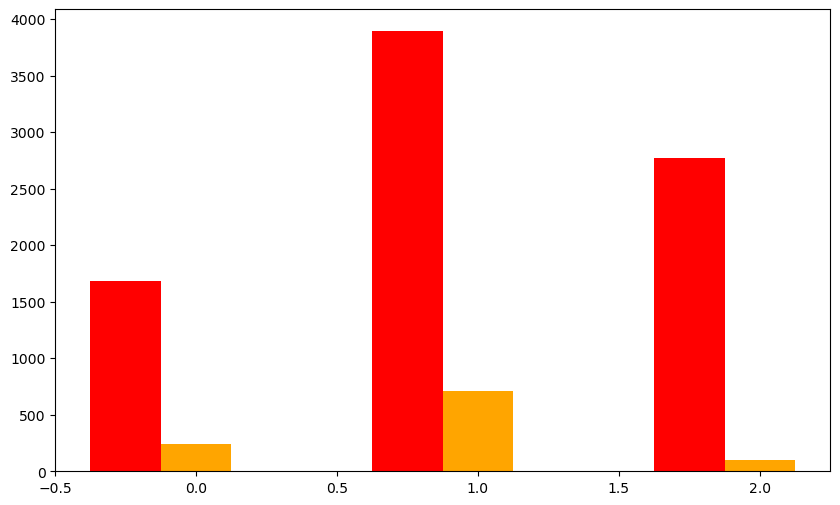

In [38]:
print(len(sample_0), len(idxs_0_p[0]))
print(len(puff_0_post_values), len(idxs_0_po[0]))

print(len(puff_4_pre_values), len(idxs_4_pr[0]))
print(len(sample_4), len(idxs_4_po[0]))

print(len(puff_5_pre_values), len(idxs_5_pr[0]))
print(len(sample_5), len(idxs_5_po[0]))

print(np.mean(sample_0), np.mean(idxs_0_p[0]))
print(np.mean(puff_0_post_values), np.mean(idxs_0_po[0]))

print(np.mean(puff_4_pre_values), np.mean(idxs_4_pr[0]))
print(np.mean(sample_4), np.mean(idxs_4_po[0]))

print(np.mean(puff_5_pre_values), np.mean(idxs_5_pr[0]))
print(np.mean(sample_5), np.mean(idxs_5_po[0]))



types = ["Sequence I", "Sequence II", "Sequence III"]
total_ripples = [1680,  3893, 2776]   # Sessions that yielded results
percentage_pre = [240, 713, 102]    
percentage_post =  [151, 584, 86]

# Corrected data
non_zero_pre = [240, 713, 102]    
non_zero_post = [151, 584, 86]

# Calculate percentages
percentage_non_zero_pre = [(nz / total) * 100 for nz, total in zip(non_zero_pre, total_ripples)]
percentage_non_zero_post = [(nz / total) * 100 for nz, total in zip(non_zero_post, total_ripples)]

# Plot positions
plt.figure(figsize=(10, 6))
x = np.arange(len(types))
bar_width = 0.25

# Plotting the bars with percentages
plt.bar(x - bar_width, total_ripples, bar_width, label="Total Ripples", color="red")
plt.bar(x, percentage_pre, bar_width, label="Pre (Non-Zero %)", color="orange")
plt.bar(x + bar_width, percentage_post, bar_width, label="Post (Non-Zero %)", color="")

# Adding annotations above the bars
for i in range(len(types)):
    # Total ripples text
    # plt.text(x[i] - bar_width, total_ripples[i] + 50, str(total_ripples[i]), 
    #          ha='center', color='black', fontsize=9)
    # Pre percentage text
    plt.text(x[i], percentage_pre[i] + 100, f"{percentage_non_zero_pre[i]:.1f}%", 
             ha='center', color='black', fontsize=9)
    # Post percentage text
    plt.text(x[i] + bar_width, percentage_post[i] + 100, f"{percentage_non_zero_post[i]:.1f}%", 
             ha='center', color='black', fontsize=9)

# Adding labels, title, and legend
plt.ylabel("Count / Percentage")
# plt.title("Total Ripples and Percentage of Non-Zero Values (Pre vs Post)")
plt.xticks(x, types)  # Set x-axis labels to the sequence types
plt.ylim(0, max(total_ripples) + 200)  # Adjust y-axis limit
# plt.legend()

# Display the plot
plt.show()


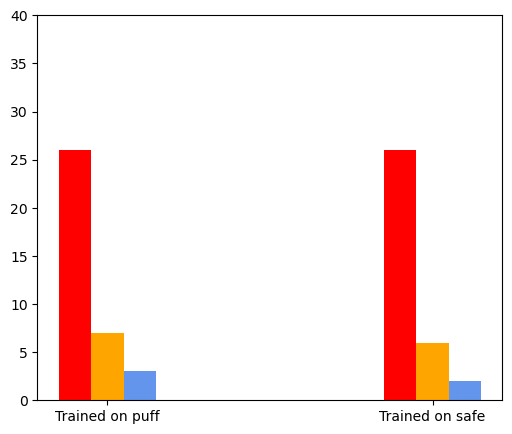

In [9]:
types = ["Trained on puff", "Trained on safe"]
# rat 11, trained on puff: 5 resultaten, 2 meer dan 1 significant neuron (echt)
# rat 10, trained on puff: 1 resultaat, 1 meer dan 1 significant neuron
# rat 08, trained on puff: 1 resultaat, 0 meer dan 1 significant neuron 
total_sessions = [26, 26]  # Total number of sessions
yielded_results = [7, 6]   # Sessions that yielded results
failed_results = [3, 2]     # Sessions that failed to yield results

# Bar chart positions
x = np.arange(len(total_sessions))  # Position of each session
plt.figure(figsize=(6,5))
# Bar width
bar_width = 0.10

# Plotting the bars
plt.bar(x - bar_width, total_sessions, bar_width, label="Total sessions", color="red")
plt.bar(x, yielded_results, bar_width, label="Found significant neuron(s)", color="orange")
plt.bar(x + bar_width, failed_results, bar_width, label="Found a sequence", color="cornflowerblue")

# for i in range(len(types)):
#     plt.text(x[i] - bar_width, total_sessions[i] + 0.5, str(total_sessions[i]), ha='center', color='black')
#     plt.text(x[i], yielded_results[i] + 0.5, str(yielded_results[i]), ha='center', color='black')
#     plt.text(x[i] + bar_width, failed_results[i] + 0.5, str(failed_results[i]), ha='center', color='black')


# Adding labels, title, and legend
# plt.ylabel("Count")
plt.ylim(0,40)
# plt.legend()
plt.xticks(x, types)  # Set
plt.savefig('valid_sessions.svg')
plt.show()

In [33]:
for i in flatten(data_puff_ripples):
    print(np.mean(i))

0.024471348883928563
0.012117442921386409
0.014953907360726125
0.0118045952966042
0.019755509569852055
0.01502208447859268


In [30]:
# PUFF
seq_r11_s5 = [15, 32, 48, 16]
fr_r11_s5 = [15, 7, 16, 40, 31]

seq_r11_s6 = [26]
fr_r11_s6 = [13, 14, 26, 26, 22]

seq_r11_s10 = [1]
fr_r11_s10 = [2, 5, 7, 0, 22]

seq_r11_s12 = [38]
fr_r11_s12 = [14, 17, 19, 38, 44]

seq_r11_s13 = [40, 39, 59, 71]
fr_r11_s13 = [73, 71, 59, 7, 39]

seq_r10_s5 = [7, 1]
fr_r10_s5 = [3, 5, 1, 7, 10]

seq_r8_s2 = [9]
fr_r8_s2 = [18, 9, 30, 12, 27]

In [48]:
# SAFE
se_r10_s1 = [3, 27, 21, 13, 4, 26, 2, 35]
f_r10_s1 = [4, 10, 17, 31, 16]

se_r10_s7 = [23]
f_r10_s7 = [23, 8, 6, 11, 3]

se_r10_s9 = [7]
f_r10_s9 = [4, 7, 6, 5, 8]

se_r11_s5 = [40]
f_r11_s5 = [21, 32, 15, 29, 16]

se_r11_s10 = [1]
f_r11_s10 = [3, 5, 9, 0, 1]

se_r11_s13= [42, 61, 47, 39]
f_r11_s13 = [75, 7, 73, 26, 61]

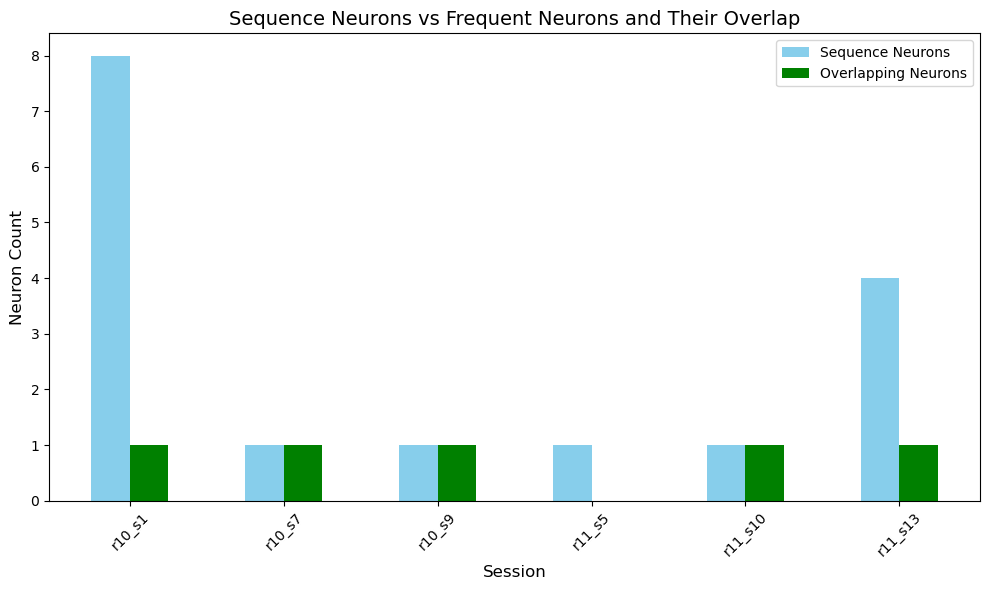

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Data for each session
data_p = {
    "r11_s5": {"seq": [15, 32, 48, 16], "fr": [15, 7, 16, 40, 31]},
    "r11_s6": {"seq": [26], "fr": [13, 14, 26, 26, 22]},
    "r11_s10": {"seq": [1], "fr": [2, 5, 7, 0, 22]},
    "r11_s12": {"seq": [38], "fr": [14, 17, 19, 38, 44]},
    "r11_s13": {"seq": [40, 39, 59, 71], "fr": [73, 71, 59, 7, 39]},
    "r10_s5": {"seq": [7, 1], "fr": [3, 5, 1, 7, 10]},
    "r8_s2": {"seq": [9], "fr": [18, 9, 30, 12, 27]},
}

data_safe = {
    "r10_s1": {"seq": [3, 27, 21, 13, 4, 26, 2, 35], "fr": [4, 10, 17, 31, 16]},
    "r10_s7": {"seq": [23], "fr": [23, 8, 6, 11, 3]},
    "r10_s9": {"seq": [7], "fr": [4, 7, 6, 5, 8]},
    "r11_s5": {"seq": [40], "fr": [21, 32, 15, 29, 16]},
    "r11_s10": {"seq": [1], "fr": [3, 5, 9, 0, 1]},
    "r11_s13": {"seq": [42, 61, 47, 39], "fr": [75, 7, 73, 26, 61]},
}

# Process data
sessions = []
sequence_counts = []
frequent_counts = []
overlap_counts = []

for session, values in data_safe.items():
    seq_neurons = values["seq"]
    fr_neurons = values["fr"]
    
    overlap = set(seq_neurons).intersection(fr_neurons)
    
    sessions.append(session)
    sequence_counts.append(len(seq_neurons))
    frequent_counts.append(len(fr_neurons))
    overlap_counts.append(len(overlap))

# Plotting
x = np.arange(len(sessions))  # Position of bars on x-axis
bar_width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - 0.5 * bar_width, sequence_counts, width=bar_width, label='Sequence Neurons', color='skyblue')
# plt.bar(x, frequent_counts, width=bar_width, label='Frequent Neurons', color='orange')
plt.bar(x + 0.5 * bar_width, overlap_counts, width=bar_width, label='Overlapping Neurons', color='green')

# Adding labels and titles
plt.xlabel('Session', fontsize=12)
plt.ylabel('Neuron Count', fontsize=12)
plt.title('Sequence Neurons vs Frequent Neurons and Their Overlap', fontsize=14)
plt.xticks(x, sessions, rotation=45)
plt.legend()
plt.tight_layout()

# Display the plot
plt.show()
